In [1]:
#pip install pandas matplotlib seaborn

# E-Commerce Sales Analysis

## Problem Statement
The objective of this project is to analyze retail sales data to identify trends, customer behavior, and opportunities to increase revenue and improve business performance.

In [2]:
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")

print("Path to dataset files:", path)

100%|██████████| 480k/480k [00:00<00:00, 77.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rohitsahoo/sales-forecasting/versions/2


In [4]:
# List the contents of the downloaded directory to find the CSV file
file_names = os.listdir(path)

# Assuming there is only one CSV file or we know its name
csv_file = [f for f in file_names if f.endswith('.csv')][0]

# Construct the full path to the CSV file
full_csv_path = os.path.join(path, csv_file)

df = pd.read_csv(full_csv_path)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Check nulls
print(df.isnull().sum())

# Drop duplicates
df = df.drop_duplicates()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [9]:
# Fill missing 'Postal Code'
mode_postal_code = df['Postal Code'].mode()[0]
df['Postal Code'] = df['Postal Code'].fillna(mode_postal_code)
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


In [10]:
# Total Sales
total_sales = df['Sales'].sum()

# Average Order Value
avg_order_value = df['Sales'].mean()

# Total Orders
total_orders = df['Order ID'].nunique()

print("Total Sales:", total_sales)
print("Average Order Value:", avg_order_value)
print("Total Orders:", total_orders)

Total Sales: 2261536.7827000003
Average Order Value: 230.7690594591837
Total Orders: 4922


In [11]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()

The month with the highest sales is November with total sales of 350161.71.


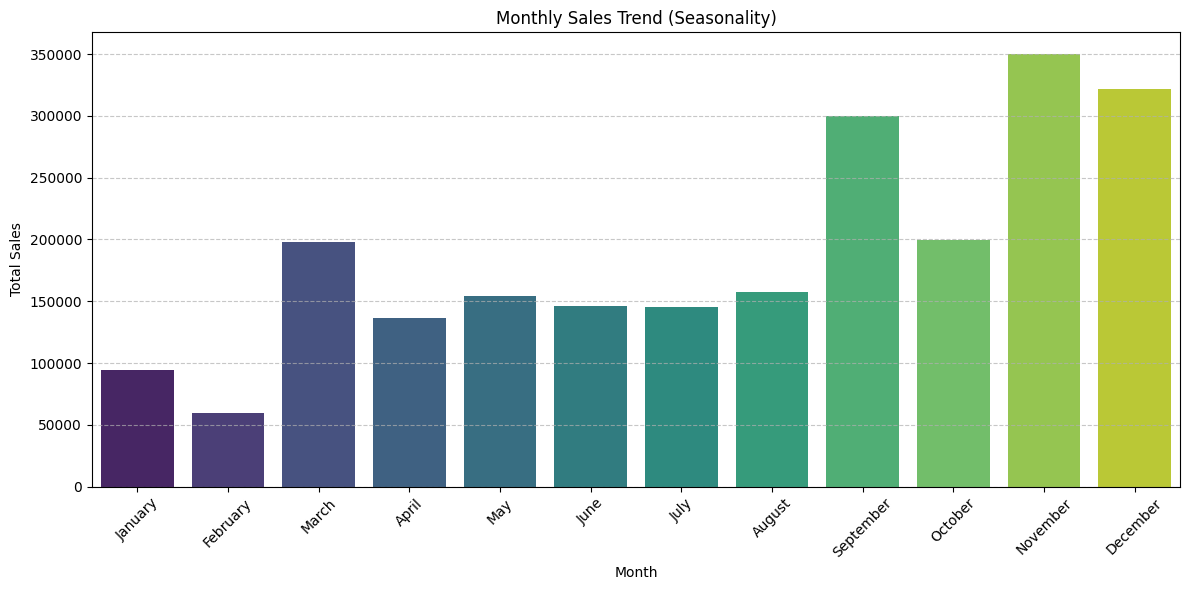

In [12]:
# Calculate total sales per month
monthly_sales = df.groupby('Month Name')['Sales'].sum().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
)

# Find the month with the highest sales
top_selling_month = monthly_sales.idxmax()
max_sales = monthly_sales.max()

print(f"The month with the highest sales is {top_selling_month} with total sales of {max_sales:.2f}.")

# Plotting seasonality trends
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, hue=monthly_sales.index, palette='viridis', legend=False)
plt.title('Monthly Sales Trend (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Category sales

<Axes: title={'center': 'Sales by Category'}, xlabel='Category'>

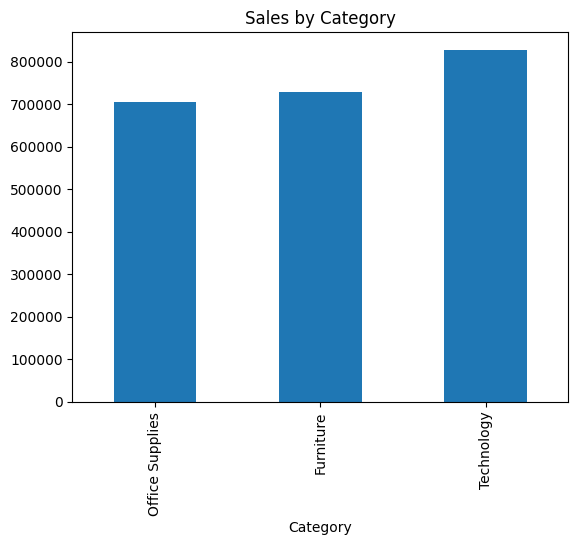

In [13]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

category_sales.plot(kind='bar', title='Sales by Category')

Regional sales

<Axes: title={'center': 'Sales by Region'}, xlabel='Region'>

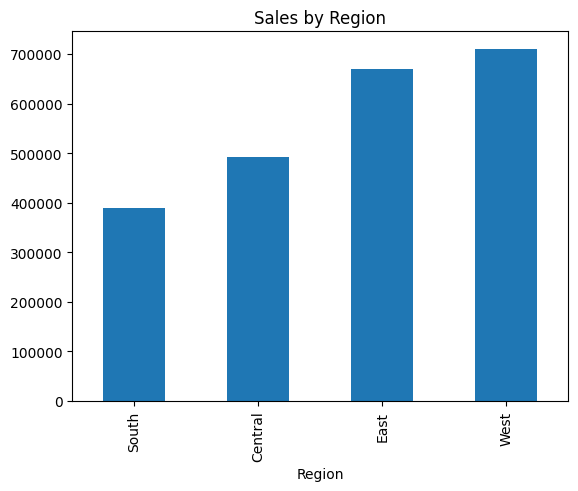

In [14]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

region_sales.plot(kind='bar', title='Sales by Region')

Monthly sales


<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Month'>

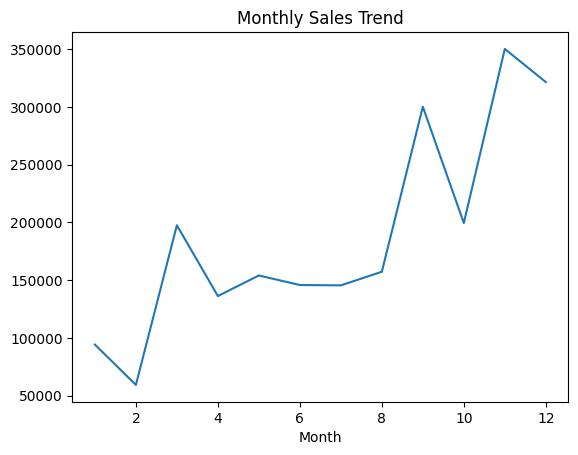

In [15]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line', title='Monthly Sales Trend')

<Axes: title={'center': 'Yearly Sales Trend'}, xlabel='Year'>

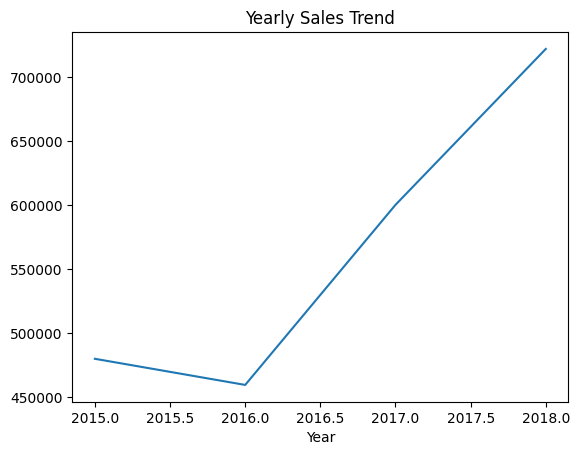

In [16]:
yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_sales.plot(kind='line', title='Yearly Sales Trend')

Top Products

<Axes: title={'center': 'Top 10 Products'}, xlabel='Product Name'>

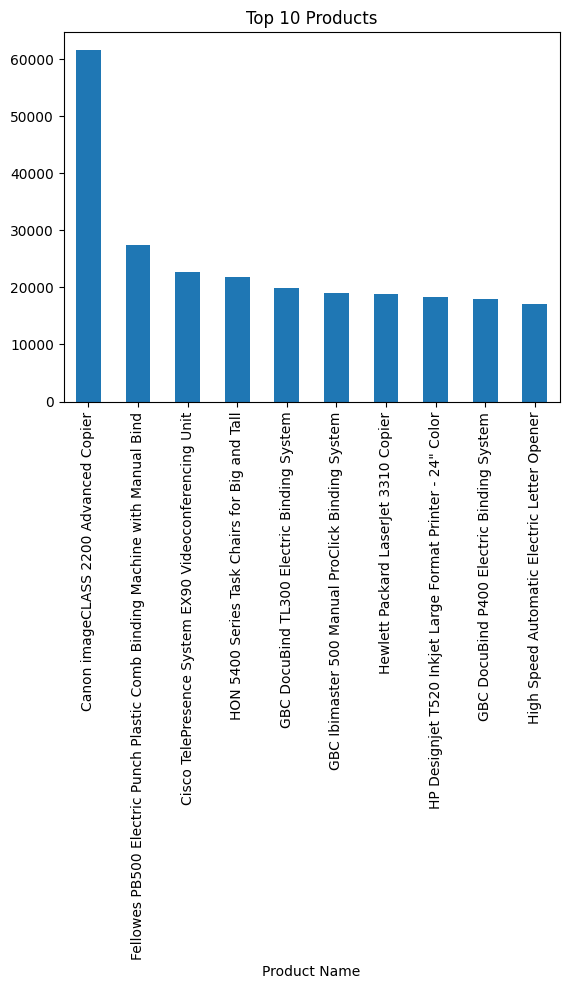

In [17]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', title='Top 10 Products')

<Axes: title={'center': 'Top 10 Cities by Sales'}, xlabel='City'>

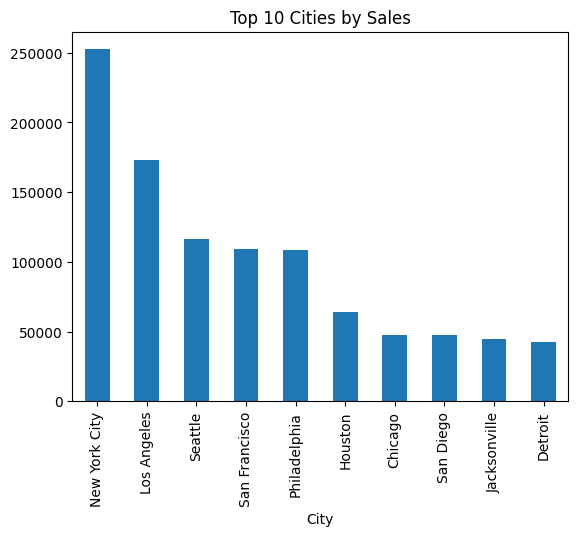

In [21]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
top_cities.plot(kind='bar', title='Top 10 Cities by Sales')

<Axes: title={'center': 'Sales by Sub-Category'}, ylabel='Sub-Category'>

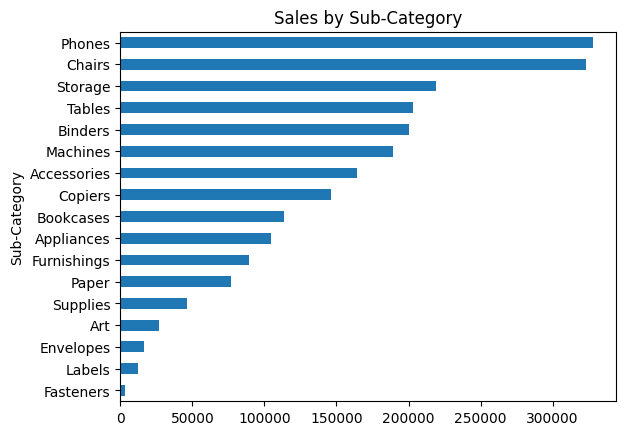

In [22]:
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values()
subcat_sales.plot(kind='barh', title='Sales by Sub-Category')

<Axes: title={'center': 'Sales by Shipping Mode'}, xlabel='Ship Mode'>

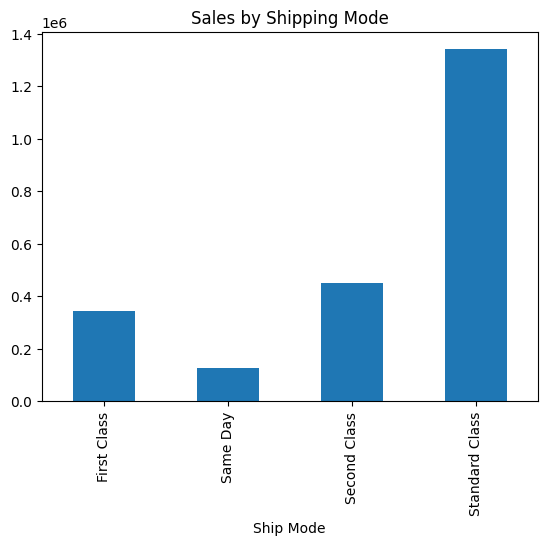

In [23]:
ship_mode_sales = df.groupby('Ship Mode')['Sales'].sum()
ship_mode_sales.plot(kind='bar', title='Sales by Shipping Mode')

Our top customers


<Axes: title={'center': 'Top Customers'}, xlabel='Customer Name'>

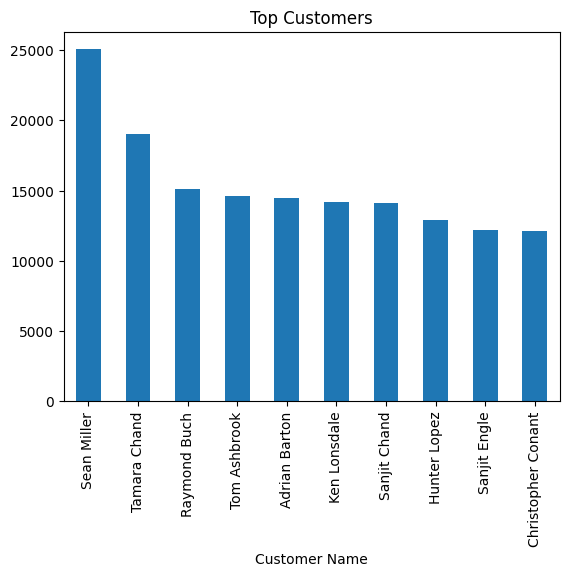

In [18]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar', title='Top Customers')

Segment sales

<Axes: title={'center': 'Sales by Segment'}, xlabel='Segment'>

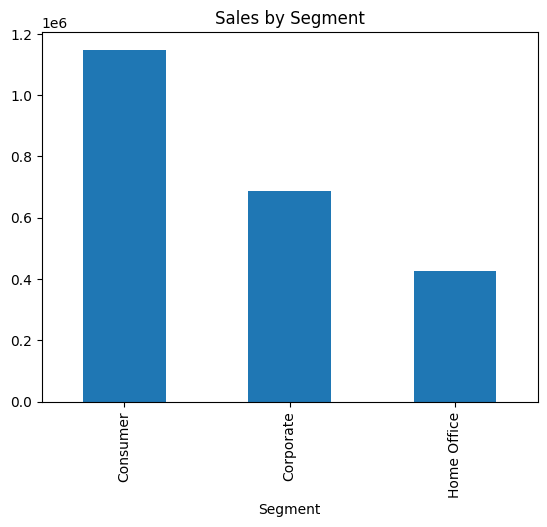

In [19]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='bar', title='Sales by Segment')

## Key Insights

1. The business generated total sales of approximately 2.26M, indicating strong overall performance.

2. Sales show clear seasonality, with peak performance observed in high-demand months, suggesting the influence of seasonal trends.

3. The Consumer segment contributes the highest share of revenue, making it the most valuable customer group.

4. A small group of top customers contributes significantly to total sales, indicating customer concentration risk.

5. Certain categories and sub-categories dominate sales, while others underperform, highlighting opportunities for optimization.

6. Regional analysis shows uneven performance across regions, suggesting potential for expansion in low-performing areas.

7. A limited number of products drive a large portion of revenue, confirming the Pareto principle (80/20 rule).

Heat map


<Axes: xlabel='Region', ylabel='Category'>

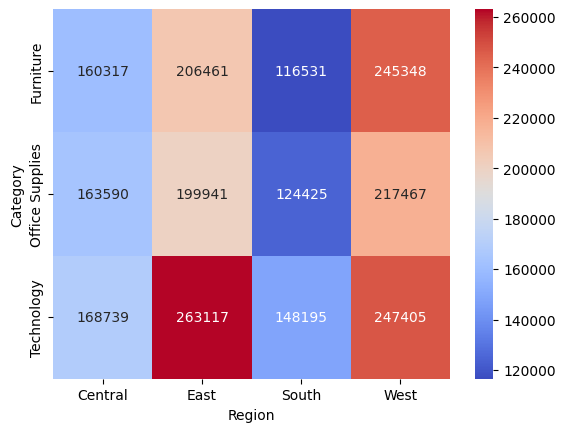

In [20]:
pivot = df.pivot_table(values='Sales', index='Category', columns='Region', aggfunc='sum')

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm")

## Business Recommendations

- Focus marketing and inventory planning around high-performing months to maximize revenue.

- Strengthen customer retention strategies for top customers through loyalty programs.

- Expand business operations in high-performing regions while improving strategies in underperforming regions.

- Optimize product portfolio by promoting high-performing products and reviewing low-performing ones.

- Target the Consumer segment with personalized campaigns to further boost sales.

- Improve logistics strategy by analyzing shipping modes to enhance delivery efficiency.

## Conclusion

This project demonstrates how data analysis can be used to uncover valuable business insights, identify trends, and support data-driven decision-making in a retail environment.